## Objectifs du TD
Identifier et visualiser les verbes les plus associés aux personnages masculins et féminins dans un corpus littéraire, en suivant une démarche descriptive sans méthodes prédictives.

## Étapes à suivre 

### 1. Chargement des données
- Charger les fichiers `.book` et combiner les informations en une seule structure de données.

### 2. Identification du genre
- Extraire clairement le genre (masculin ou féminin) de chaque personnage à partir des informations disponibles.

### 3. Extraction des verbes
- Pour chaque personnage, lister tous les verbes associés directement au personnage (actions réalisées par ce personnage).

### 4. Calcul des proportions de verbes associés à chaque genre
- Pour chaque verbe fréquent (présent chez au moins 1% des personnages du corpus), calculer :
  - Le nombre de personnages masculins associés au verbe.
  - Le nombre de personnages féminins associés au verbe.

### 5. Calculer le score d'association détaillé
- Pour chaque verbe, appliquer la formule suivante :

\[
\text{Score d'association} = \frac{\text{Nombre de personnages masculins associés au verbe} - \text{Nombre de personnages féminins associés au verbe}}{\text{Nombre de personnages masculins associés au verbe} + \text{Nombre de personnages féminins associés au verbe}}
\]


#### Explication détaillée du score
- Un score positif indique que le verbe est davantage associé aux personnages masculins.
- Un score négatif indique que le verbe est davantage associé aux personnages féminins.
- Si le score est proche de 0, le verbe est associé de manière équilibrée aux deux genres.

### 6. Visualisation
- Créer un graphique à barres où les verbes seront ordonnés selon leur score d'association.
- Utiliser des couleurs contrastées pour visualiser clairement la tendance masculine ou féminine des verbes.

## Interprétation
- Observer quels verbes sont typiquement associés aux personnages masculins ou féminins pour identifier les biais linguistiques liés au genre dans la littérature analysée.
- Identifier clairement les tendances narratives et les stéréotypes potentiels présents dans le corpus.

In [1]:
import json

In [2]:
path_book = "BOOK_FILES/1880_Zola-Emile_Nana.book"

In [3]:
def read_booknlp(path_book):
    with open(path_book, "r", encoding="utf-8") as file:
        lines = file.readlines()
        dicts = [eval(line.strip()) for line in lines if line.strip()]
        # eval() transforme une chaîne de caractères représentant un dictionnaire en objet Python
    return dicts

In [4]:
book_nana = read_booknlp(path_book)

### Le premier personnage est donc bien Nana

In [12]:
book_nana[0]['gender']["argmax"]

'Female'

In [56]:
book_nana[0]["mentions"]['proper'][0]

{'n': 'nana', 'c': 821}

In [26]:
 book_nana[0]["mentions"].keys()

dict_keys(['proper', 'common', 'pronoun'])

In [28]:
book_nana[0]["agent"]

[{'w': 'devoir', 'i': 561},
 {'w': 'avoir', 'i': 1237},
 {'w': 'savoir', 'i': 1282},
 {'w': 'cher', 'i': 1419},
 {'w': 'joue', 'i': 1422},
 {'w': 'avoir', 'i': 1482},
 {'w': 'avoir', 'i': 1527},
 {'w': 'aller', 'i': 1569},
 {'w': 'aller', 'i': 1579},
 {'w': 'tomber', 'i': 2265},
 {'w': 'venir', 'i': 2522},
 {'w': 'répondre', 'i': 2551},
 {'w': 'avoir', 'i': 2555},
 {'w': 'aimer', 'i': 2560},
 {'w': 'oser', 'i': 2576},
 {'w': 'dire', 'i': 2602},
 {'w': 'connaître', 'i': 2605},
 {'w': 'voir', 'i': 2616},
 {'w': 'coucher', 'i': 2630},
 {'w': 'sonner', 'i': 2887},
 {'w': 'attendre', 'i': 5228},
 {'w': 'descendre', 'i': 5580},
 {'w': 'entamer', 'i': 5596},
 {'w': 'chanter', 'i': 5646},
 {'w': 'savoir', 'i': 5654},
 {'w': 'jeter', 'i': 5663},
 {'w': 'voir', 'i': 5759},
 {'w': 'devenir', 'i': 5768},
 {'w': 'mettre', 'i': 5850},
 {'w': 'attendre', 'i': 5883},
 {'w': 'avoir', 'i': 5916},
 {'w': 'faire', 'i': 5928},
 {'w': 'avoir', 'i': 5933},
 {'w': 'commencer', 'i': 5961},
 {'w': 'gratter', 'i

In [29]:
agent_nana = book_nana[0]["agent"]

In [32]:
liste_mots_nana = []
for elem in agent_nana:
    liste_mots_nana.append(elem["w"])

In [34]:
from collections import Counter

In [35]:
dict_conteur = Counter(liste_mots_nana)

In [38]:
dict_conteur.most_common(10)

[('avoir', 151),
 ('dire', 109),
 ('vouloir', 71),
 ('faire', 58),
 ('savoir', 53),
 ('aller', 49),
 ('pouvoir', 45),
 ('trouver', 37),
 ('voir', 36),
 ('prendre', 31)]

In [88]:
def charac_gender(mot, dico_booknlp):
    count_female, count_male = 0, 0
    for personnage in dico_booknlp[:30]:
        gender = personnage['gender']["argmax"]

        liste_mots_perso_courant = []
        for elem in personnage["agent"]:
            liste_mots_perso_courant.append(elem["w"])

        dico_mots_perso_courant = dict(Counter(liste_mots_perso_courant))

        if mot not in dico_mots_perso_courant:
            # certain personnage n'ont pas le mot demandé - on passe à l'étape de boucle suivante
            continue
        else:
            if gender == "Female":
                count_female+= dico_mots_perso_courant[mot]
            if gender == "Male":
                count_male+= dico_mots_perso_courant[mot]
    return count_female, count_male
        

In [87]:
charac_gender('devoir', book_nana)

(56, 58)

In [90]:
liste_verbes = ["poursuivre", "découvrir", "tirer", "courir", "manger", "trouver", "adorer", "aimer", 'rire', 'crier', "danser"]  # Remplacer par vos verbes fréquents

In [94]:
scores = []
for elem in liste_verbes:
    scores.append(charac_gender(elem, book_nana))

In [95]:
scores

[(1, 0),
 (1, 1),
 (6, 4),
 (14, 5),
 (9, 11),
 (63, 57),
 (7, 4),
 (34, 27),
 (10, 8),
 (38, 27),
 (5, 0)]

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
df = pd.DataFrame(scores, columns=["Female", "Male"], index=liste_verbes).reset_index().rename(columns={"index":"verbe"})

In [102]:
# Compute normalized score in [-1, 1]
df["score"] = (df["Female"] - df["Male"]) / (df["Female"] + df["Male"]).replace(0, np.nan)
df["score"] = df["score"].fillna(0)  # in case of 0/0 (not present), set neutral

# Color mapping: blue for more féminin (score >= 0), red for more masculin (score < 0)
colors = ["blue" if s >= 0 else "red" for s in df["score"]]

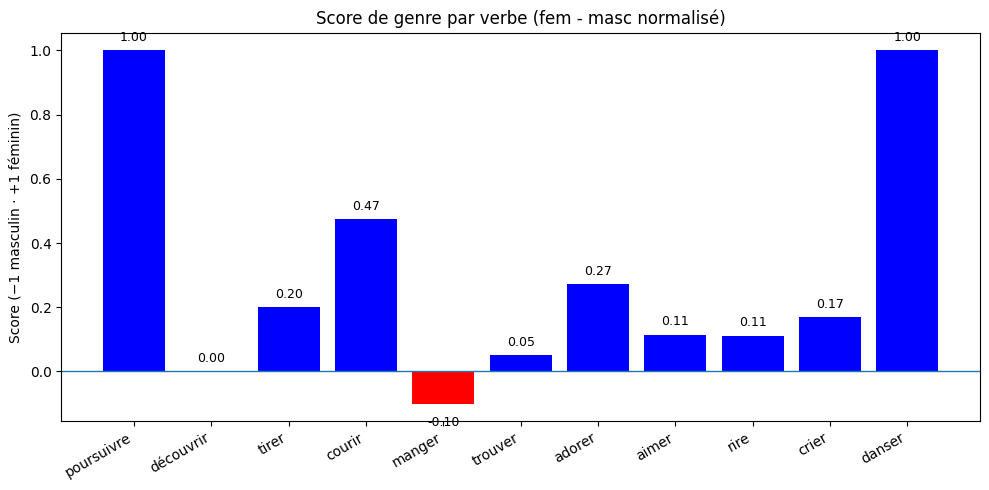

In [101]:
# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(df["verbe"], df["score"], color=colors)
plt.axhline(0, linewidth=1)
plt.title("Score de genre par verbe (fem - masc normalisé)")
plt.ylabel("Score (−1 masculin · +1 féminin)")
plt.xticks(rotation=30, ha="right")

# Annotate bars with values
for bar, s in zip(bars, df["score"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.02 if height >= 0 else -0.04),
             f"{s:.2f}", ha="center", va="bottom" if height >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()


# Lecture CSV métadonnées

In [39]:
import pandas as pd

In [42]:
df_meta = pd.read_csv("CHAPITRES_METADATA.csv", index_col="doc_name")

In [44]:
df_meta["genre"].value_counts()

genre
roman d'aventures               364
policier                        307
roman historique                207
nouvelles                       186
cycles et séries                174
littérature jeunesse            146
mémoires et autobiographie      136
roman sentimental               133
érotisme                        107
fantastique                      66
récit de voyage                  34
épistolaire                      33
science-fiction                  31
non-fiction                      25
fragments                        16
journal intime                    8
biographie                        5
roman historique                  3
 nouvelles                        2
 mémoires et autobiographie       2
littérature à contraintes         1
 roman sentimental                1
littérature jeunesse              1
ciné-roman                        1
 littérature jeunesse             1
Name: count, dtype: int64